In [61]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [62]:
# create the environment -> grid, states, actions, rewards, obstacles
grid = 5
start_state = (0,0)
goal_state = (4,4)
obstacles = [(1,1), (2,2), (3,1)]

#actions = ['up', 'down', 'left', 'right']
actions = {
    0: (0, -1),   # Left
    1: (0, 1),    # Right
    2: (-1, 0),   # Up
    3: (1, 0)     # Down
}

In [63]:
# create Q- table init = 0 & hyperparameters
Q_table = np.zeros((grid,grid,4))             # (grid**2, len(actions))

gamma = 0.65
alpha = 0.1
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01
episodes = 2000

In [64]:
# create the step function to handle the steps and the boundries and rewards
def step(state, action):
    row, col = state
    dr, dc = actions[action]

    new_row, new_col = row + dr, col + dc

    if 0 <= new_row < grid and 0 <= new_col < grid:
        next_state = (new_row, new_col)
    else:
        next_state = (row, col)

    if next_state in obstacles:
        return next_state, -10, True         # terminal (obstacel)
    if next_state == goal_state:
        return next_state, +10, True         # terminal (goal)

    return next_state, -1, False             # normal step ( penalty )

In [65]:
# training loop & use epsilon greedy
rewards_history = []

for episode in range(episodes):
    state = start_state
    done = False
    episode_reward = 0  # Track reward for the current episode

    while not done:
        # Epsilon-greedy action selection
        if random.uniform(0, 1) < epsilon:
            action = random.choice(list(actions.keys()))
        else:
            action = np.argmax(Q_table[state[0], state[1]])

        next_state, reward, done = step(state, action)

        row, col = state
        next_row, next_col = next_state

        if done:
            target = reward
        else:
            best_next_q = np.max(Q_table[next_row, next_col])
            target = reward + gamma * best_next_q

        Q_table[row, col, action] += alpha * (target - Q_table[row, col, action])

        state = next_state
        episode_reward += reward  # Accumulate the reward

    # Save the total reward of the episode
    rewards_history.append(episode_reward)

    # Decrease epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print("Training completed")

Training completed


In [66]:
state = start_state
done = False
steps = 0
path = [state]
max_steps = 25

while not done and steps < max_steps:
    action = np.argmax(Q_table[state[0], state[1]])

    next_state, reward, done = step(state, action)

    path.append(next_state)
    state = next_state
    steps += 1

if state == goal_state:
    print(f"Success! Reached the goal in {steps} steps.")
elif state in obstacles:
    print(f"Failed! Hit an obstacle at {state}.")
else:
    print("Failed! Timed out (reached max steps).")

Success! Reached the goal in 8 steps.


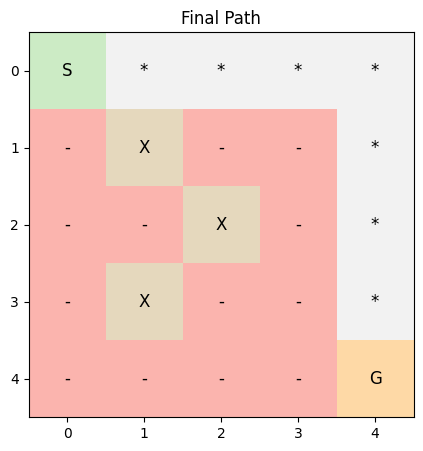

In [67]:
grid_display = np.full((grid, grid), '-')
grid_display[start_state] = 'S'
grid_display[goal_state] = 'G'
for obs in obstacles:
    grid_display[obs] = 'X'
for position in path:
    if position != start_state and position != goal_state and position not in obstacles:
        grid_display[position] = '*'

visual_grid = np.zeros((grid, grid))
for i in range(grid):
    for j in range(grid):
        if grid_display[i, j] == 'S': visual_grid[i, j] = 1
        elif grid_display[i, j] == 'G': visual_grid[i, j] = 2
        elif grid_display[i, j] == 'X': visual_grid[i, j] = 3
        elif grid_display[i, j] == '*': visual_grid[i, j] = 4

plt.figure(figsize=(5, 5))
plt.imshow(visual_grid, cmap='Pastel1')
for i in range(grid):
    for j in range(grid):
        plt.text(j, i, grid_display[i, j], ha='center', va='center', fontsize=12)
plt.title("Final Path")
plt.show()

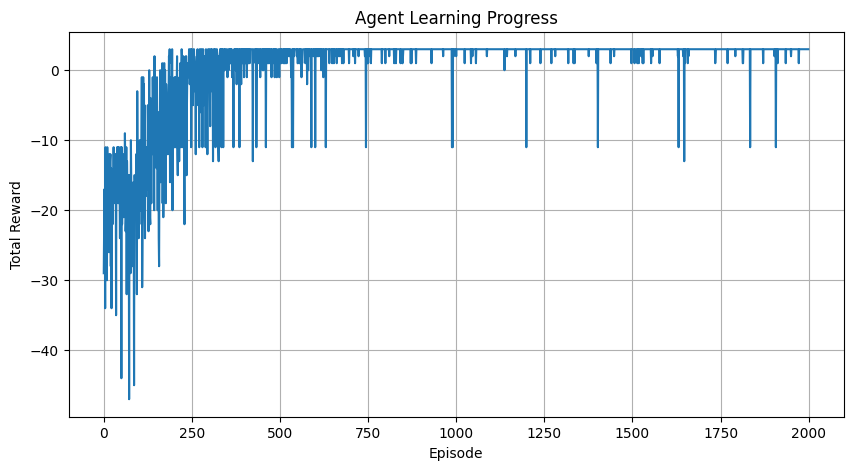

In [68]:
plt.figure(figsize=(10, 5))
plt.plot(rewards_history)
plt.title("Agent Learning Progress")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

In [69]:
output = (
    f"Final Path: {path}\n"
    f"Final Reward: {reward}\n"
    f"Final Epsilon: {epsilon}\n"
    f"Number of Steps: {steps}\n"
    f"Q-Table:\n{Q_table}\n"
)

print(output)

Final Path: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]
Final Reward: 10
Final Epsilon: 0.01
Number of Steps: 8
Q-Table:
[[[-2.47058411 -2.22685641 -2.46111335 -2.50652062]
  [-2.44195517 -1.88747141 -2.24411124 -9.99543224]
  [-2.23050076 -1.36534063 -1.92623971 -1.60001566]
  [-1.88726506 -0.5620625  -1.42861042 -0.68826336]
  [-1.3926762  -0.69045686 -0.661051    0.67375   ]]

 [[-2.3605461  -9.85219117 -2.35685127 -2.35832062]
  [ 0.          0.          0.          0.        ]
  [-8.33228183 -0.69217671 -1.77448711 -6.86189404]
  [-1.46856725  0.67184199 -1.31453444 -0.76889788]
  [-0.6743335   0.48743134 -0.66090676  2.575     ]]

 [[-2.15340528 -2.14508137 -2.16550201 -2.13073566]
  [-2.08600563 -3.439      -6.12579511 -5.217031  ]
  [ 0.          0.          0.          0.        ]
  [-4.0951     -0.0947328  -0.61604915  2.13062265]
  [-0.06729917  1.94146638  0.57388374  5.5       ]]

 [[-1.91443448 -6.86189404 -1.84092274 -1.68215548]
  [ 0.      